In [ ]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, 
                                     BatchNormalization, ReLU, GlobalAveragePooling1D, Reshape, multiply, add)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define the paths
DATA_DIR_FAKE = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/combined_fake_ecgs"
DATA_DIR_REAL = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/real_ecgs"

def load_lead_I_from_asc(file_path):
    try:
        # Load the .asc file
        ecg_data = np.loadtxt(file_path)
        # Extract Lead I
        lead_I = ecg_data[:, 0]
        return lead_I
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def load_exactly_2000_lead_I_from_directory(data_dir, n=2000):
    all_lead_I = []
    i = 0
    with tqdm(total=n, desc=f"Loading Lead I from {data_dir.split('/')[-1]}", unit='file') as pbar:
        while len(all_lead_I) < n:
            file_name = f"{i}.asc"
            file_path = os.path.join(data_dir, file_name)
            if os.path.exists(file_path):
                lead_I = load_lead_I_from_asc(file_path)
                if lead_I is not None:
                    all_lead_I.append(lead_I)
                    pbar.update(1)
            i += 1
    return np.array(all_lead_I)

# Load exactly 2000 Lead I ECG records from both directories
lead_I_real = load_exactly_2000_lead_I_from_directory(DATA_DIR_REAL, n=2000)
lead_I_fake = load_exactly_2000_lead_I_from_directory(DATA_DIR_FAKE, n=2000)

if lead_I_fake.size > 0 and lead_I_real.size > 0:
    print(f"Total Lead I records loaded from real data: {lead_I_real.shape[0]}")
    print(f"Total Lead I records loaded from fake data: {lead_I_fake.shape[0]}")
else:
    print("No data was loaded.")


Loading Lead I from combined_fake_ecgs: 100%|██████████| 2000/2000 [00:21<00:00, 94.00file/s] 

Total Lead I records loaded from real data: 2000
Total Lead I records loaded from fake data: 2000


In [2]:
def min_max_normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    return 2 * (data - min_val) / (max_val - min_val) - 1

lead_I_real = np.array([min_max_normalize(ecg) for ecg in lead_I_real])
lead_I_fake = np.array([min_max_normalize(ecg) for ecg in lead_I_fake])

# Combine data and labels
X = np.concatenate((lead_I_fake, lead_I_real), axis=0)
y = np.concatenate((np.zeros(lead_I_fake.shape[0]), np.ones(lead_I_real.shape[0])), axis=0)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Reshape data to (samples, time_steps, 1)
INPUT_SHAPE = (X_train.shape[1], 1)
X_train = X_train.reshape(-1, X_train.shape[1], 1)
X_test = X_test.reshape(-1, X_test.shape[1], 1)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (3200, 5000, 1)
X_test shape: (800, 5000, 1)


In [ ]:

# ---- ResNet-Attention Model Definition ----

def squeeze_excite_block(input_tensor, ratio=16):
    """Squeeze-and-Excitation block for channel-wise attention."""
    filters = input_tensor.shape[-1]
    se = GlobalAveragePooling1D()(input_tensor)
    se = Reshape((1, filters))(se)
    se = Dense(filters // ratio, activation='relu',
               kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid',
               kernel_initializer='he_normal', use_bias=False)(se)
    x = multiply([input_tensor, se])
    return x

def res_block(x, filters, kernel_size=3, stride=1):
    """Residual block with squeeze-and-excitation attention."""
    shortcut = x
    # First convolutional layer
    x = Conv1D(filters, kernel_size, strides=stride, padding='same', 
               kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    # Second convolutional layer
    x = Conv1D(filters, kernel_size, strides=1, padding='same', 
               kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    # Attention module
    x = squeeze_excite_block(x)
    # Adjust shortcut dimensions if necessary
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same', 
                          kernel_initializer='he_normal')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    # Add shortcut connection and apply activation
    x = add([x, shortcut])
    x = ReLU()(x)
    return x

# Build the model using the functional API
inputs = Input(shape=INPUT_SHAPE)
# Initial convolution layer
x = Conv1D(32, kernel_size=3, padding='same', kernel_initializer='he_normal')(inputs)
x = BatchNormalization()(x)
x = ReLU()(x)

# First Residual Block (32 filters)
x = res_block(x, 32, kernel_size=3, stride=1)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.25)(x)

# Second Residual Block (64 filters)
x = res_block(x, 64, kernel_size=3, stride=1)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.25)(x)

# Third Residual Block (128 filters)
x = res_block(x, 128, kernel_size=3, stride=1)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.25)(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.25)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model
optimizer = Adam(learning_rate=0.005)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# EarlyStopping callback to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1)

# Train the model
batch_size = 32
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=batch_size,
                    validation_data=(X_test, y_test), 
                    callbacks=[early_stop])

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Save the model
# model.save("my_ecg_model.h5")
# print("Model saved successfully.")

Epoch 1/50
100/100 [==============================] - 123s 1s/step - loss: 10.4979 - accuracy: 0.7328 - val_loss: 0.6507 - val_accuracy: 0.7063
Epoch 2/50
100/100 [==============================] - 114s 1s/step - loss: 0.2799 - accuracy: 0.8906 - val_loss: 0.5286 - val_accuracy: 0.7225
Epoch 3/50
100/100 [==============================] - 115s 1s/step - loss: 0.1480 - accuracy: 0.9500 - val_loss: 0.3630 - val_accuracy: 0.8338
Epoch 4/50
100/100 [==============================] - 114s 1s/step - loss: 0.1049 - accuracy: 0.9644 - val_loss: 0.2753 - val_accuracy: 0.9200
Epoch 5/50
100/100 [==============================] - 114s 1s/step - loss: 0.0343 - accuracy: 0.9881 - val_loss: 0.0862 - val_accuracy: 0.9837
Epoch 6/50
100/100 [==============================] - 114s 1s/step - loss: 0.0634 - accuracy: 0.9819 - val_loss: 0.5875 - val_accuracy: 0.8562
Epoch 7/50
100/100 [==============================] - 113s 1s/step - loss: 0.0237 - accuracy: 0.9937 - val_loss: 0.0266 - val_accuracy: 0.995

c:\Users\M2-Winterfell\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved successfully.


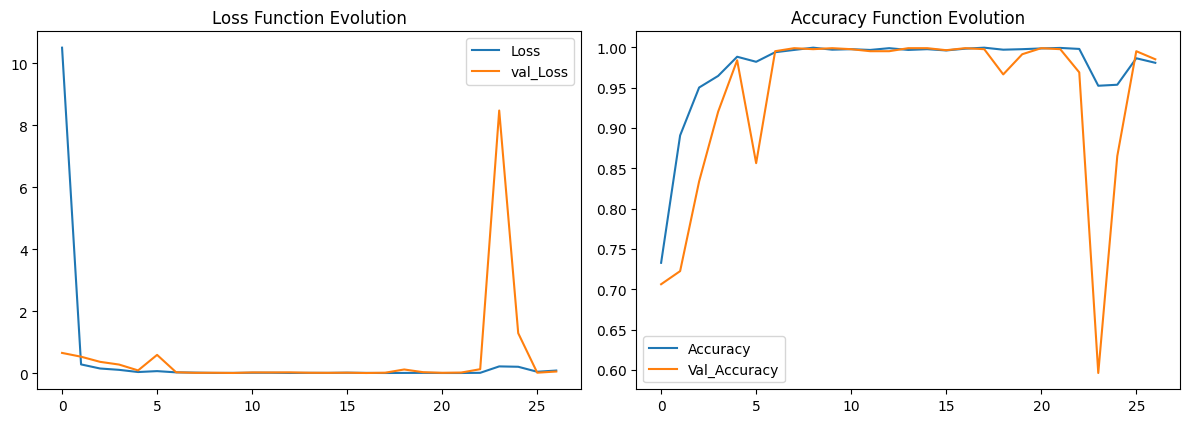

In [4]:
# Plotting Training History
plt.figure(figsize=(12, 16))

# Loss plot
plt.subplot(4, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='val_Loss')
plt.title('Loss Function Evolution')
plt.legend()

# Accuracy plot
plt.subplot(4, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val_Accuracy')
plt.title('Accuracy Function Evolution')
plt.legend()

plt.tight_layout()
plt.show()

25/25 [==============================] - 4s 172ms/step - loss: 0.0509 - accuracy: 0.9850
Test Accuracy: 98.50%
25/25 [==============================] - 5s 169ms/step


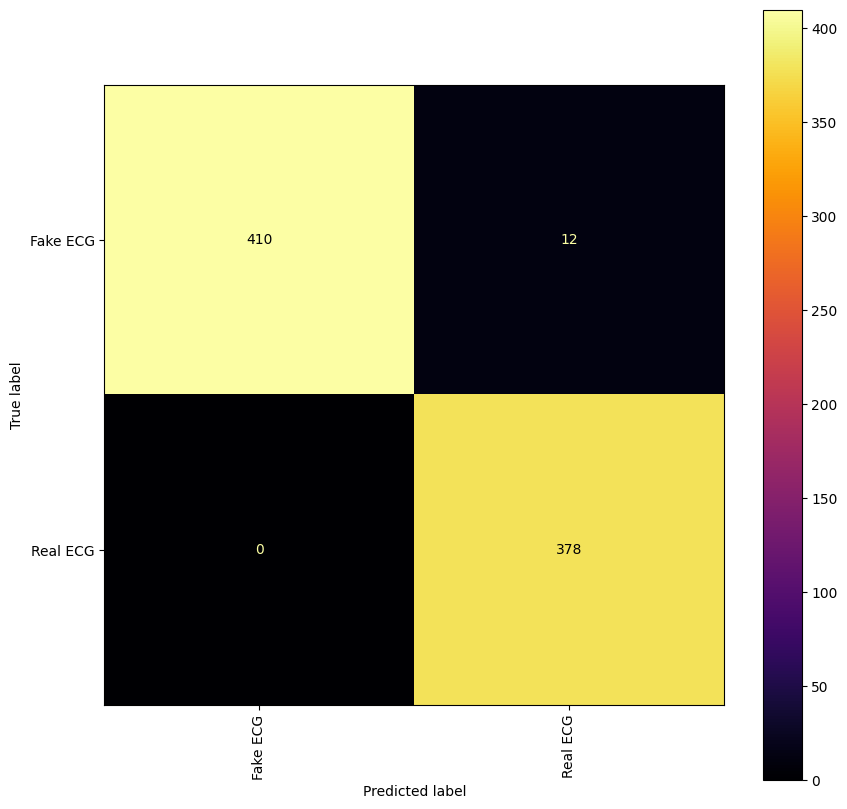

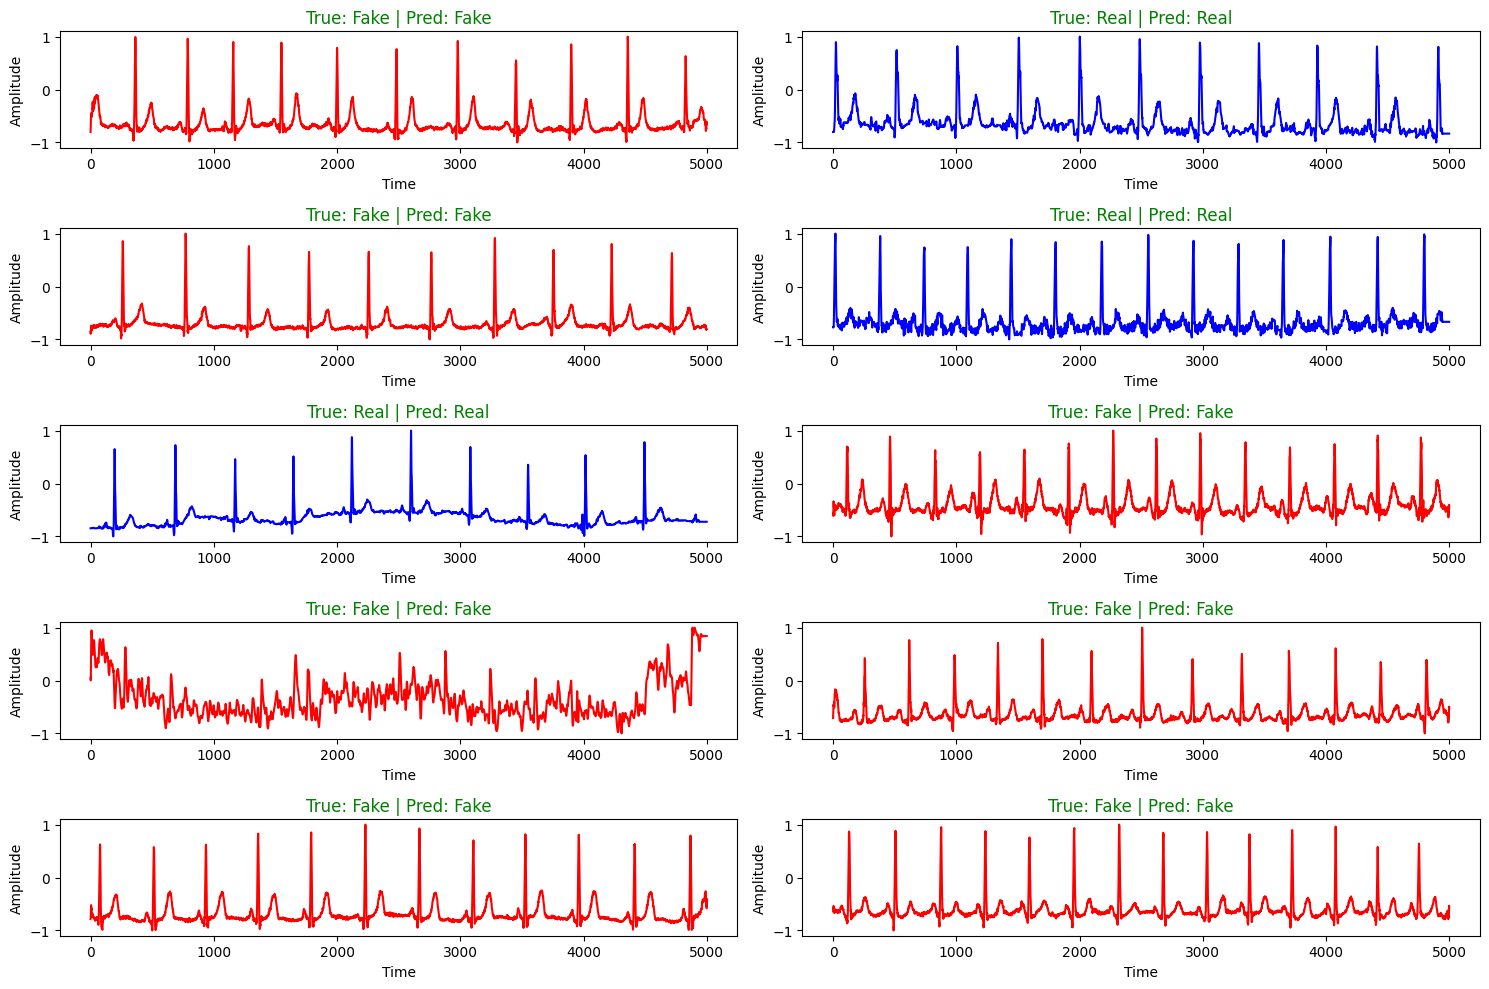

In [5]:
# Model Evaluation and Confusion Matrix
evaluation = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {evaluation[1] * 100:.2f}%")

# Predict on test set and convert probabilities to binary labels
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype("int32").flatten()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake ECG", "Real ECG"])

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(xticks_rotation='vertical', ax=ax, cmap='inferno')
plt.show()

# Visualizing some ECG signals along with predictions
num_samples = 10
plt.figure(figsize=(15, 10))
for i in range(num_samples):
    plt.subplot(5, 2, i + 1)
    plt.plot(X_test[i].squeeze(), color='blue' if y_test[i] == 1 else 'red')
    plt.title(f"True: {'Real' if y_test[i] == 1 else 'Fake'} | Pred: {'Real' if y_pred[i] == 1 else 'Fake'}",
              color='green' if y_test[i] == y_pred[i] else 'red')
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

Model loaded successfully.
1/1 [==============================] - 0s 24ms/step
Processed 1000 files.
Accuracy: 100.00%


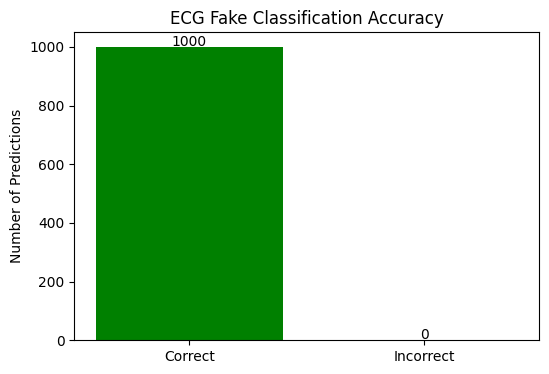

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Define the normalization function
def min_max_normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    return 2 * (data - min_val) / (max_val - min_val) - 1

# Load the pre-trained model
model_path = "C:/Users/M2-Winterfell/Downloads/my_ecg_resnet_model.h5"
loaded_model = load_model(model_path)
print("Model loaded successfully.")

# Path to the folder containing the fake ECG .asc files
folder_path = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/cnn_fake"

total_files = 0
correct_predictions = 0

# Loop over files named 0.asc to 999.asc
for i in range(1000):
    file_path = os.path.join(folder_path, f"{i}.asc")
    try:
        # Load ECG data from the file
        ecg_data = np.loadtxt(file_path)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        continue

    # If the file has multiple columns, take the first (Lead I)
    if ecg_data.ndim > 1:
        ecg_data = ecg_data[:, 0]

    # Normalize the ECG data
    ecg_data = min_max_normalize(ecg_data)

    # Reshape data to add batch and channel dimensions
    ecg_data = ecg_data.reshape(1, 5000, 1)

    # Predict the probability that the signal is "Real"
    prediction_prob = loaded_model.predict(ecg_data)
    prediction_label = "Real" if prediction_prob[0][0] > 0.5 else "Fake"

    # Since all files are supposed to be fake, count a correct prediction if the label is "Fake"
    if prediction_label == "Fake":
        correct_predictions += 1

    total_files += 1

# Compute and display the overall accuracy
accuracy = correct_predictions / total_files * 100
print(f"Processed {total_files} files.")
print(f"Accuracy: {accuracy:.2f}%")

# Visualize the results with a bar chart
labels = ['Correct', 'Incorrect']
counts = [correct_predictions, total_files - correct_predictions]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, counts, color=['green', 'red'])
plt.title('ECG Fake Classification Accuracy')
plt.ylabel('Number of Predictions')

# Annotate the bars with counts
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 5, f'{int(height)}', ha='center')

plt.show()